In [3]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd

# Import and analyse noise dataset

In [4]:
noise_streets = gpd.read_file("../../layers/BCN_noise_streets.gpkg")
print(noise_streets.crs)  #CRS = Coordinate Reference System
print(noise_streets.shape)
print(noise_streets.columns.tolist())
print("Number of street segments:", len(noise_streets))

EPSG:25831
(15115, 30)
['TRAM', 'TOTAL_D', 'TOTAL_E', 'TOTAL_N', 'TOTAL_DEN', 'TRANSIT_D', 'TRANSIT_E', 'TRANSIT_N', 'TRANSIT_DEN', 'GI_TR_D', 'GI_TR_E', 'GI_TR_N', 'GI_TR_DEN', 'FFCC_D', 'FFCC_E', 'FFCC_N', 'FFCC_DEN', 'INDUST_D', 'INDUST_E', 'INDUST_N', 'INDUST_DEN', 'VIANANTS_D', 'VIANANTS_E', 'OCI_N', 'PATIS_D', 'PATIS_E', 'geometry_type', 'start', 'end', 'geometry']
Number of street segments: 15115


## Interactive map

In [ ]:
noise_streets.explore()

## Plot the noise during day, evening and night with same legend

Text(0.5, 1.0, 'Night')

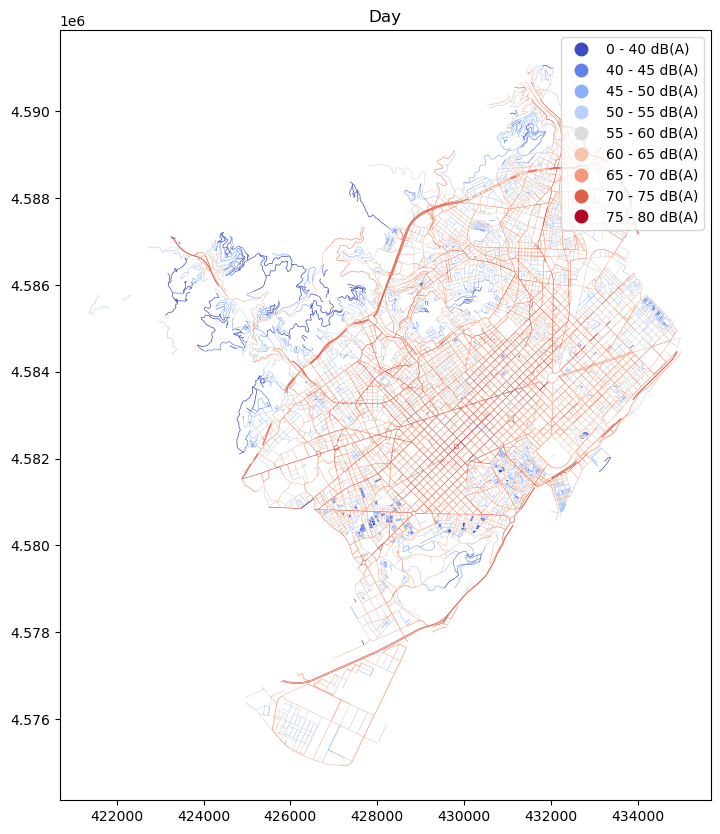

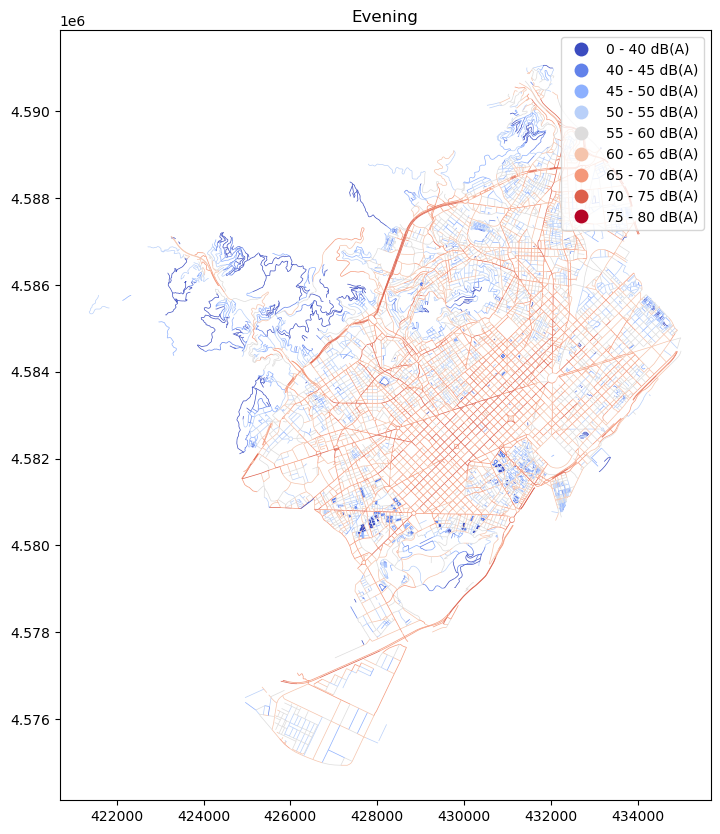

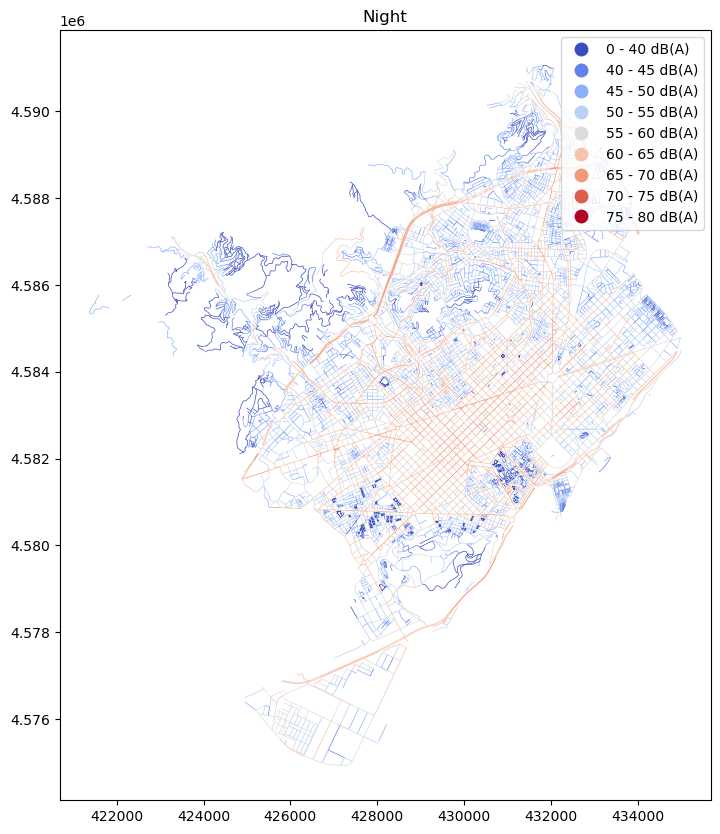

In [ ]:
# Make a copy of the dataset to avoid modifying the original
gdf = noise_streets.copy()

# Get all unique categories from all three columns combined
all_categories = sorted(set(
    list(gdf['TOTAL_D'].unique()) + 
    list(gdf['TOTAL_E'].unique()) + 
    list(gdf['TOTAL_N'].unique())
))

# Convert all three columns to categorical with the same categories
gdf['TOTAL_D'] = pd.Categorical(gdf['TOTAL_D'], categories=all_categories, ordered=True)
gdf['TOTAL_E'] = pd.Categorical(gdf['TOTAL_E'], categories=all_categories, ordered=True)
gdf['TOTAL_N'] = pd.Categorical(gdf['TOTAL_N'], categories=all_categories, ordered=True)

# Plot Day
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(column='TOTAL_D', cmap='coolwarm', linewidth=0.5, legend=True, ax=ax)
ax.set_title('Day')

# Plot Evening
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(column='TOTAL_E', cmap='coolwarm', linewidth=0.5, legend=True, ax=ax)
ax.set_title('Evening')

# Plot Night
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(column='TOTAL_N', cmap='coolwarm', linewidth=0.5, legend=True, ax=ax)
ax.set_title('Night')

## Histograms

### Noise day

In [ ]:
counts_day = gdf.groupby('TOTAL_D').size()

# Move last category < 40 dB(A) to first position
counts_day = pd.concat([counts_day.iloc[[-1]], counts_day.iloc[:-1]])
print(counts_day)

NameError: name 'gdf' is not defined

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# Create bar chart
counts_day.plot(kind='bar', ax=ax, edgecolor='black', color='steelblue')
ax.set_title('Number of Streets by Day Noise Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Noise evening

In [ ]:
counts_evening = noise_streets.groupby('noise_evening').size()

# Move last category < 40 dB(A) to first position
counts_evening = pd.concat([counts_evening.iloc[[-1]], counts_evening.iloc[:-1]])
print(counts_evening)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# Create bar chart
counts_evening.plot(kind='bar', ax=ax, edgecolor='black', color='steelblue')
ax.set_title('Number of Streets by Evening Noise Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Noise night

In [ ]:
counts_night = noise_streets.groupby('noise_night').size()

# Move last category < 40 dB(A) to first position
counts_night = pd.concat([counts_night.iloc[[-1]], counts_night.iloc[:-1]])
print(counts_night)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# Create bar chart
counts_night.plot(kind='bar', ax=ax, edgecolor='black', color='steelblue')
ax.set_title('Number of Streets by Night Noise Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Noise day, evening, night

In [ ]:
# Get counts for all three periods
counts_day = noise_streets.groupby('noise_day').size()
counts_evening = noise_streets.groupby('noise_evening').size()
counts_night = noise_streets.groupby('noise_night').size()

# Create a DataFrame with all three series
comparison_df = pd.DataFrame({
    'Day': counts_day,
    'Evening': counts_evening,
    'Night': counts_night
})

comparison_df = pd.concat([comparison_df.iloc[[-1]], comparison_df.iloc[:-1]])

print(comparison_df)

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

# Create grouped bar chart
comparison_df.plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
ax.set_title('Number of Streets by Noise Level (Day, Evening, Night)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()